In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.feature_selection import chi2
from sklearn.preprocessing import StandardScaler,LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [54]:
df=pd.read_csv('Housing_data.csv')
print('show 5 columns:\n', df.head())
print('show number of rows and columns:df=p\n', df.shape)

show 5 columns:
    Price  LivingArea  Bathrooms  Bedrooms  LotSize  Age  Fireplace
0  16858        1629        1.0         3     0.76  180          0
1  26049        1344        2.0         3     0.92   13          0
2  26130         822        1.0         2     0.56  173          0
3  31113        1540        1.0         2     0.04  115          0
4  40932        1320        1.0         3     0.17   90          0
show number of rows and columns:df=p
 (1047, 7)


In [55]:
df.dtypes

Price           int64
LivingArea      int64
Bathrooms     float64
Bedrooms        int64
LotSize       float64
Age             int64
Fireplace       int64
dtype: object

# 1) HANDLING MISSING VALUES

In [56]:
df.isnull().sum()

Price         0
LivingArea    0
Bathrooms     0
Bedrooms      0
LotSize       0
Age           0
Fireplace     0
dtype: int64

# 2) HANDLING MISSING VALUES

In [57]:
df.duplicated().sum()

np.int64(12)

In [58]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# 3) OUTLIER DETECTION AND CAPPING

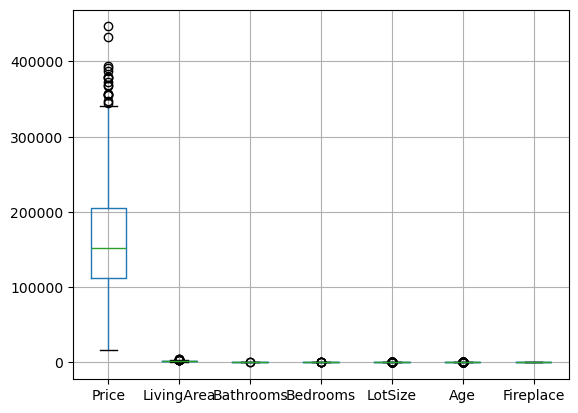

In [59]:
df.boxplot()
plt.show()

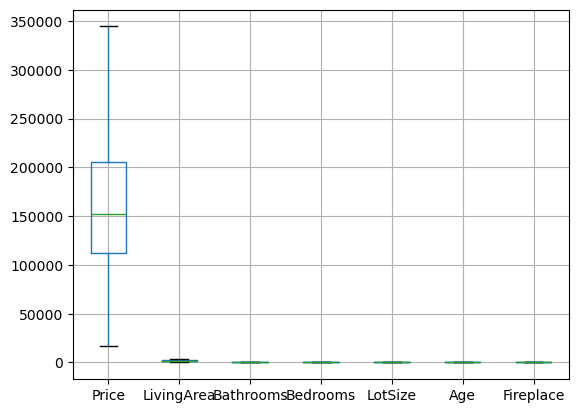

In [60]:
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df[column]=df[column].apply( lambda x: lower if x  <lower else upper if x> upper else x) 
for col in df.select_dtypes(['int','float']).columns:
     outlier_capping(df,col)
df.boxplot()
plt.show()

# 4) FEATURE SELECTION

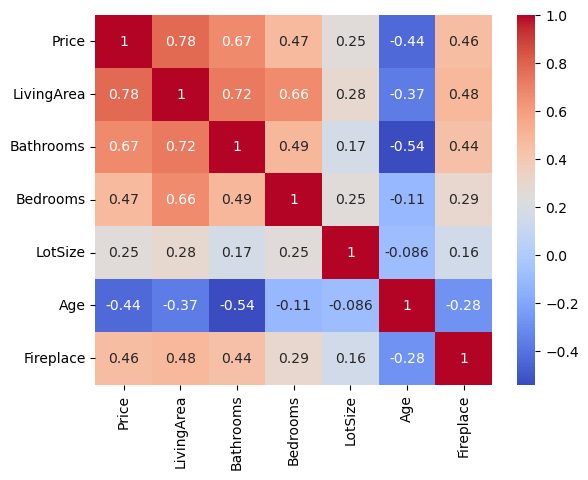

Correlation btw features and target:
 Price         1.000000
LivingArea    0.779461
Bathrooms     0.672573
Bedrooms      0.472767
Fireplace     0.462812
LotSize       0.250458
Age          -0.438123
Name: Price, dtype: float64
 Best features:
 Price         1.000000
LivingArea    0.779461
Bathrooms     0.672573
Name: Price, dtype: float64


In [63]:
corr=df.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()
print('Correlation btw features and target:\n',corr['Price'].sort_values(ascending=False))
print(' Best features:\n', corr['Price'][corr['Price'] >0.5].sort_values(ascending=False))

# 5) MULTICOLINEARITY

In [64]:
y=df[['Price']]
x=df.drop(columns='Price')

In [66]:
vif=pd.DataFrame()
vif['Features']=x.columns
vif['VIF']=[variance_inflation_factor(x.values,i) for i in range (len(x.columns))]
vif.sort_values(by='VIF',ascending=False)

,Features,VIF
2,Bedrooms,29.100456
0,LivingArea,28.393716
1,Bathrooms,21.617158
3,LotSize,3.345417
5,Fireplace,3.304989
4,Age,2.471556


# 6) SCALING 

In [71]:
sta_scaler=StandardScaler()
df[['LivingArea','LotSize','Age']]=sta_scaler.fit_transform(x[['LivingArea','LotSize','Age']])
x.head()

,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,1629.0,1.0,3.0,0.76,75.25,0
1,1344.0,2.0,3.0,0.92,13.00,0
2,822.0,1.0,2.0,0.56,75.25,0
3,1540.0,1.0,2.0,0.04,75.25,0
4,1320.0,1.0,3.0,0.17,75.25,0


# 7) ENCODING

In [73]:
df['Gender'] = np.random.choice(['male','female'], size=len(df))
df.head()

,Price,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace,Gender
0,16858.0,-0.277590,1.0,3.0,0.937235,2.258368,0,female
1,26049.0,-0.730058,2.0,3.0,1.437239,-0.488931,0,female
2,26130.0,-1.558790,1.0,2.0,0.312231,2.258368,0,female
3,31113.0,-0.418887,1.0,2.0,-1.312782,2.258368,0,female
4,40932.0,-0.768161,1.0,3.0,-0.906529,2.258368,0,male


In [ ]:
la_encoding=LabelEncoder()
la_encoding.fit_transform(x[['Gender']]